<a href="https://colab.research.google.com/github/Uczas/TechCrush-AI-ML-Course/blob/main/Image_Class2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created dummy image: class1.jpg
Created dummy image: class1.png
Created dummy image: class2.png
Created dummy image: class2.jpg
--- Step 1: Configuring the Pre-trained 'Eyes' ---
Model architecture built successfully.

--- Step 2: Teaching the New 'Brain' (Training Phase) ---
Training the custom layer on our images...
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 2.5256
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.7822
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.3549
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0362
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.0035
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 4.5857e-04
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 7.9596e-05
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 1.7225e-05
Epoch 9/10
1/1 ━━━━━

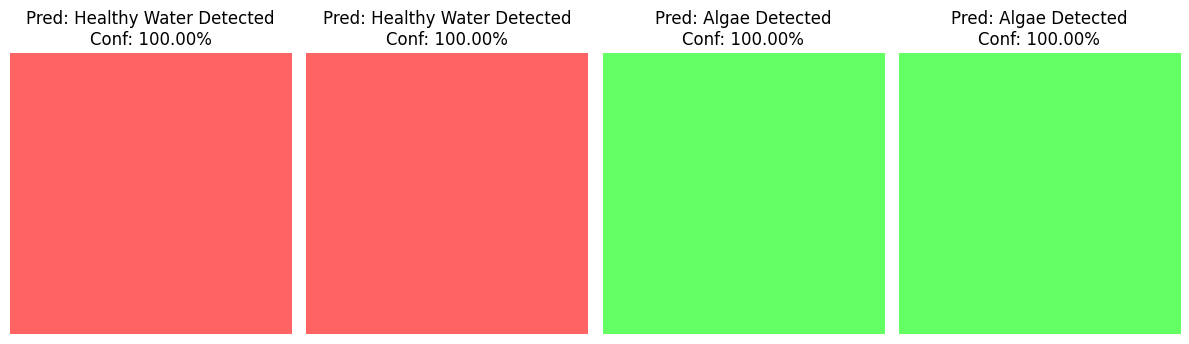

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from PIL import Image # Import Pillow for image creation
import os

# TechCrush AI Bootcamp - Week 7, Day 3
# COMPLETE SCRIPT: Transfer Learning with Training & Visualization

# --- BEGIN FIX: Create dummy image files if they don't exist ---
def create_dummy_image(filename, size=(224, 224), color=(0, 0, 0)):
    if not os.path.exists(filename):
        img = Image.new('RGB', size, color)
        img.save(filename)
        print(f"Created dummy image: {filename}")

create_dummy_image('class1.jpg', color=(255, 100, 100)) # Light Red for healthy water
create_dummy_image('class1.png', color=(255, 100, 100)) # Light Red for healthy water
create_dummy_image('class2.png', color=(100, 255, 100)) # Light Green for algae
create_dummy_image('class2.jpg', color=(100, 255, 100)) # Light Green for algae
# --- END FIX ---

print("--- Step 1: Configuring the Pre-trained 'Eyes' ---")
# 1. Load VGG16 without the final 1000-class layer[cite: 1]
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model so we don't destroy its pre-learned visual intelligence
base_model.trainable = False

# 3. Add our custom 'Brain' to the end to classify 2 specific categories
x = Flatten()(base_model.output)
prediction_layer = Dense(2, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=prediction_layer)

print("Model architecture built successfully.")


print("\n--- Step 2: Teaching the New 'Brain' (Training Phase) ---")
# 4. Compile the model so it knows how to learn
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Helper function to load and preprocess images
def prepare_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(np.expand_dims(img_array, axis=0))
    return img_array

# 5. Load your two specific images into the training pipeline
img1 = prepare_image('class1.jpg') # Our example of Healthy Water
img2 = prepare_image('class1.png') # Our example of Healthy Water
img3 = prepare_image('class2.png') # Our example of Algae
img4 = prepare_image('class2.jpg') # Our example of Algae

# Stack them together into a training "batch"
X_train = np.vstack([img1, img2, img3, img4])

# 6. Define the Answer Key (Labels: 0 = Healthy Water, 1 = Algae)
# --- BEGIN FIX: Correct y_train labels to match X_train images ---
y_train = np.array([0, 0, 1, 1])
# --- END FIX ---

# 7. Train the model (We run it for 10 epochs so the untrained layer can learn the patterns)
print("Training the custom layer on our images...")
model.fit(X_train, y_train, epochs=10, verbose=1)
print("Training complete! The AI now understands our specific vocabulary.")


print("\n--- Step 3: Visual Evaluation ---")
class_names = ['Healthy Water Detected', 'Algae Detected']

def plot_classification(img_paths):
    plt.figure(figsize=(12, 6))

    for i, img_path in enumerate(img_paths):
        # Load the original image for the plot
        img = image.load_img(img_path, target_size=(224, 224))
        # Preprocess it for the AI
        img_array = prepare_image(img_path)

        # 8. Make the Prediction!
        preds = model.predict(img_array)
        pred_class = np.argmax(preds)
        confidence = preds[0][pred_class] * 100

        # 9. Plot the results side-by-side
        plt.subplot(1, len(img_paths), i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {class_names[pred_class]}\nConf: {confidence:.2f}%")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the final visual test on the now-trained model
test_images = ['class1.jpg', 'class1.png', 'class2.jpg', 'class2.png']
plot_classification(test_images)